## Imports

In [23]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## importing the Data

In [24]:
data_dir = Path("BankData")

client = pd.read_csv("../BankData/client.csv",delimiter=";")

client

,client_id,birth_number,district_id
0,1,706213,18
1,2,450204,1
2,3,406009,1
3,4,561201,5
4,5,605703,5
...,...,...,...
5364,13955,456030,1
5365,13956,430406,1
5366,13968,680413,61
5367,13971,626019,67


## Checking for nulls

In [25]:
client.birth_number.isna().sum()

0

## rearrange for better view

In [26]:
# Pass the column names in your preferred order
new_order = ['client_id', 'district_id', 'birth_number']
client = client[new_order]

client.head()

,client_id,district_id,birth_number
0,1,18,706213
1,2,1,450204
2,3,1,406009
3,4,5,561201
4,5,5,605703


## describing the data

In [27]:
pd.DataFrame(client.describe())

,client_id,district_id,birth_number
count,5369.000000,5369.000000,5369.000000
mean,3359.011920,37.310114,535114.970013
std,2832.911984,25.043690,172895.618429
min,1.000000,1.000000,110820.000000
25%,1418.000000,14.000000,406009.000000
50%,2839.000000,38.000000,540829.000000
75%,4257.000000,60.000000,681013.000000
max,13998.000000,77.000000,875927.000000


## in the data documentation 
The value is in the form: YYMMDD (for men)
The value is in the form: YYMM+50DD (for women)

In [28]:
s = client['birth_number'].astype(str).str.zfill(6)
client['gender'] = s.str[2:4].astype(int).apply(lambda m: 'F' if m > 50 else 'M')

## parsing the birth_number

In [29]:
# 1. Convert to a 6-digit string
s = client['birth_number'].astype(str).str.zfill(6)

# 2. Extract year, month, and day
# (Note: In this dataset, female birth months have 50 added to them, e.g., 51-62)
year = '19' + s.str[0:2]
month_raw = s.str[2:4].astype(int)
month = month_raw.apply(lambda m: m - 50 if m > 50 else m).astype(str).str.zfill(2)
day = s.str[4:6]

# 3. Convert to datetime, then format to Day-Month-Year ('DD-MM-YYYY')
birth_date = pd.to_datetime(year + '-' + month + '-' + day)
client['birth_number'] = birth_date.dt.strftime('%d-%m-%Y')

client.head()

,client_id,district_id,birth_number,gender
0,1,18,13-12-1970,F
1,2,1,04-02-1945,M
2,3,1,09-10-1940,F
3,4,5,01-12-1956,M
4,5,5,03-07-1960,F


## Age Column

In [30]:
client = client.copy()

birth_year = pd.to_datetime(client['birth_number'], format='%d-%m-%Y').dt.year

client['age'] = 1996 - birth_year

client.head()

,client_id,district_id,birth_number,gender,age
0,1,18,13-12-1970,F,26
1,2,1,04-02-1945,M,51
2,3,1,09-10-1940,F,56
3,4,5,01-12-1956,M,40
4,5,5,03-07-1960,F,36


## histplot

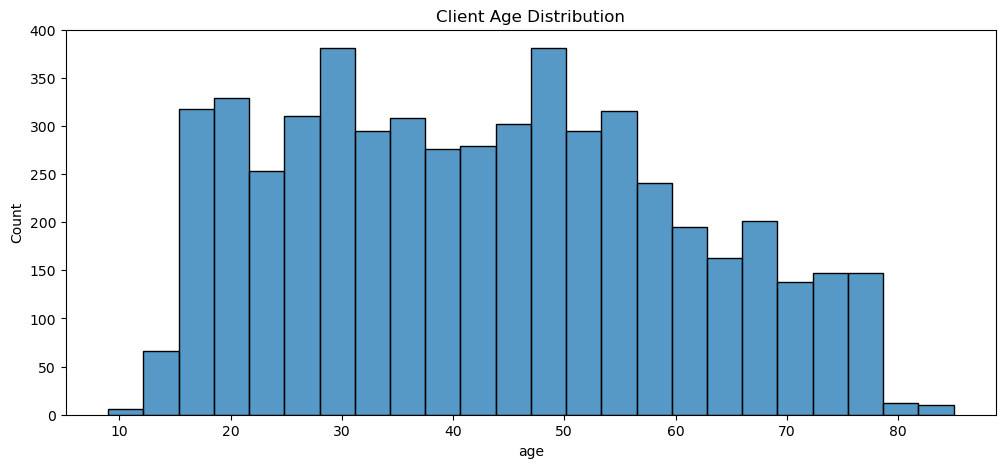

In [31]:
plt.figure(figsize=(12, 5))
sns.histplot(client['age'])
plt.title("Client Age Distribution")
plt.show()

## count plot 

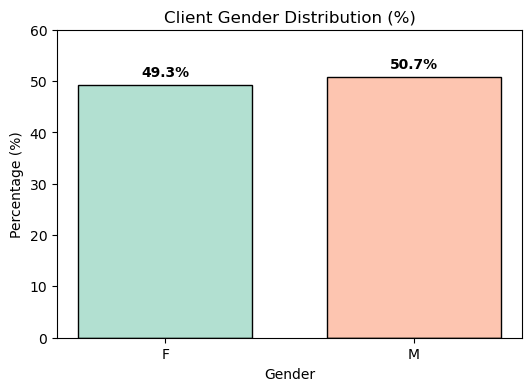

In [32]:
plt.figure(figsize=(6, 4))

# 1. Plot percentage directly on the y-axis
ax = sns.histplot(
    data=client,
    x='gender',
    stat='percent',
    discrete=True,
    shrink=0.7,
    palette='Set2',
    hue='gender',
    legend=False
)

# 2. Add percentage labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='bottom',
            fontweight='bold',
            xytext=(0, 4),
            textcoords='offset points'
        )

plt.title("Client Gender Distribution (%)")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.ylim(0, 60)  # leaves breathing room for the text above bars
plt.show()

## save the data

In [33]:
client.to_csv("../cleanData/clean_client.csv", sep=";", index=False)